In [1]:
import numpy as np
import odl

In [2]:
# 1. RECONSTRUCTION SPACE
# Downscaled for VRAM safety during prototyping, maintaining proportions
reco_space = odl.uniform_discr(
    min_pt=[-120, -150, 0],
    max_pt=[120, 150, 60],
    shape=[200, 250, 50], # Halved dimensions to save memory
    dtype='float32'
)

In [3]:
# 2. ANGLE PARTITIONS
angle_min = np.radians(-25)
angle_max = np.radians(25)   
num_views = 25
angle_partition = odl.uniform_partition(angle_min, angle_max, num_views)
full_angle_partition = odl.uniform_partition(0, 2 * np.pi, 360)

In [4]:
# 3. DETECTOR PARTITION (With Binning)
# Original: 2816 x 3584. Binning factor of 4 -> 704 x 896
# The physical size remains exactly the same
det_width_half = (2816 * 0.085) / 2.0
det_height_half = (3584 * 0.085) / 2.0

detector_partition = odl.uniform_partition(
    [-det_width_half, -det_height_half], 
    [det_width_half, det_height_half], 
    [704, 896] # Binned shape to avoid CUDA Out-Of-Memory
)

In [5]:
# 4. GEOMETRY
det_radius = 60.0 
src_radius = 590.0

geometry = odl.applications.tomo.ConeBeamGeometry(
    angle_partition, detector_partition, 
    src_radius=src_radius, det_radius=det_radius,
    axis=[0, 1, 0]
)

geometry_full = odl.applications.tomo.ConeBeamGeometry(
    full_angle_partition, detector_partition, 
    src_radius=src_radius, det_radius=det_radius,
    axis=[0, 1, 0]
)

In [6]:
# 5. FORWARD PROJECTION
phantom = odl.core.phantom.shepp_logan(reco_space, modified=True)

ray_transfo = odl.applications.tomo.RayTransform(reco_space, geometry, impl='astra_cuda')
ray_transfo_full = odl.applications.tomo.RayTransform(reco_space, geometry_full, impl='astra_cuda')

# Perfect projections
proj_data = ray_transfo(phantom)           
proj_data_full = ray_transfo_full(phantom)

In [10]:
# 6. NOISE SIMULATION (Fixed using pure NumPy)
incident_photons = 1e5

# Extract NumPy array from ODL element
proj_arr = proj_data.asarray()

# Step A: Convert attenuation to photon counts
intensity_data = incident_photons * np.exp(-proj_arr)

# Step B: Add Poisson Noise (Quantum noise)
noisy_intensity = np.random.poisson(intensity_data).astype(np.float32)

# Step C: Add Gaussian Noise (Electronic noise, std_dev = 5.0)
noisy_intensity += np.random.normal(0, 5.0, noisy_intensity.shape)

# Step D: Prevent negative values before taking the log
noisy_intensity = np.maximum(noisy_intensity, 1.0)

# Step E: Convert back to attenuation (sinogram domain)
proj_data_noisy_arr = -np.log(noisy_intensity / incident_photons)

# Re-inject the noisy NumPy array back into the ODL object
proj_data_noisy = proj_data.space.element(proj_data_noisy_arr)

In [11]:
# 7. RECONSTRUCTION
# Using Hann filter as suggested for mammography
fbp_operator = odl.applications.tomo.fbp_op(ray_transfo, filter_type='Hann') 
backproj_fdk = fbp_operator(proj_data_noisy) # Reconstruct from NOISY data

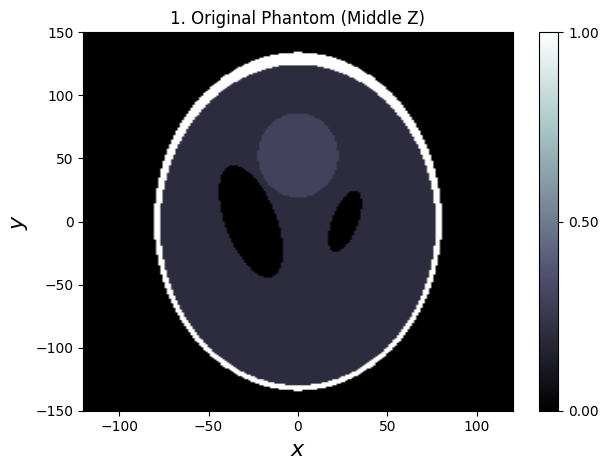

<Figure size 640x480 with 0 Axes>

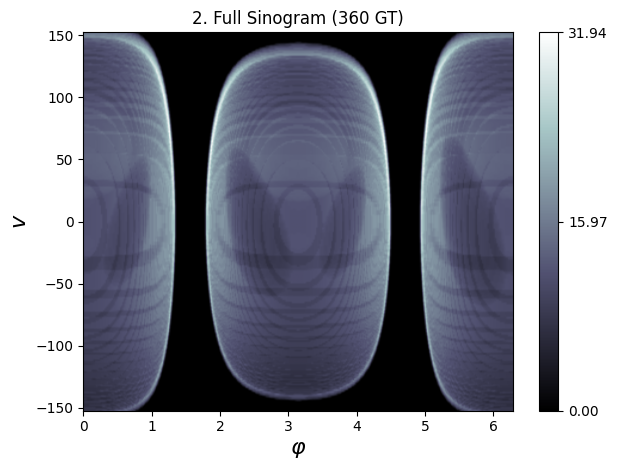

<Figure size 640x480 with 0 Axes>

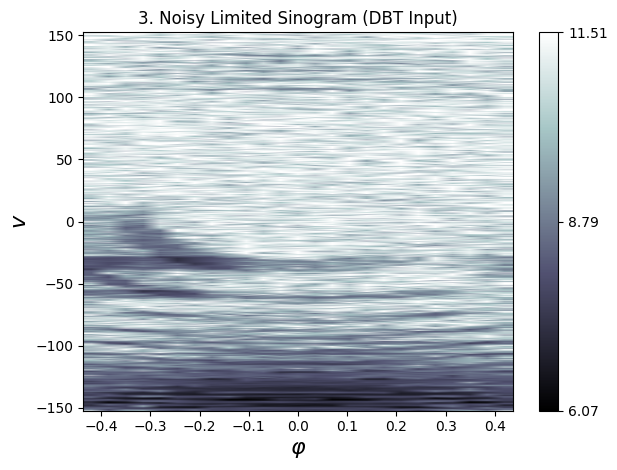

<Figure size 640x480 with 0 Axes>

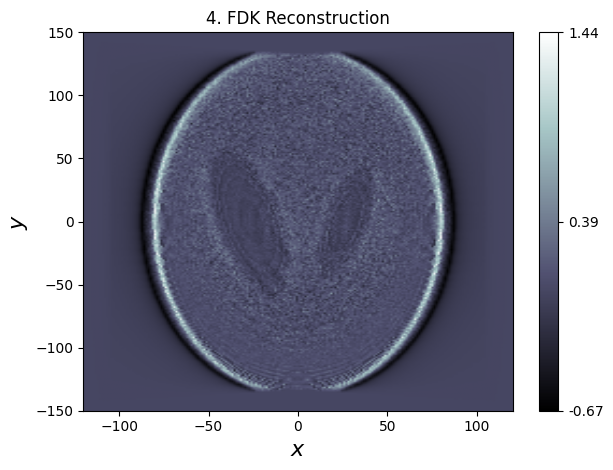

<Figure size 640x480 with 0 Axes>

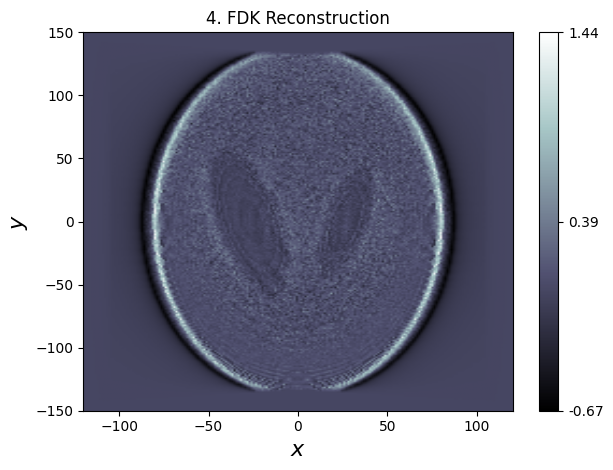

In [13]:
# 8. VISUALIZATION
# The original phantom is 3D (X, Y, Z). We fix Z=25 to see a 2D slice.
phantom.show(coords=[None, None, 25], title='1. Original Phantom (Middle Z)')

# The projection data is 3D (Angle, Detector Y, Detector X). 
# We fix Detector Y at 0 mm to see the sinogram of the central detector row.
proj_data_full.show(coords=[None, 0, None], title='2. Full Sinogram (360 GT)')
proj_data_noisy.show(coords=[None, 0, None], title='3. Noisy Limited Sinogram (DBT Input)')

# The reconstructed volume is 3D (X, Y, Z). We fix Z=25 to see the same slice as the phantom.
backproj_fdk.show(coords=[None, None, 25], title='4. FDK Reconstruction', force_show=True)

Generating Full Sinogram...
Generating Limited Sinogram...
Applying Noise...
Reconstructing DBT Volume (SIRT 20 iterations)...
Processing Complete!


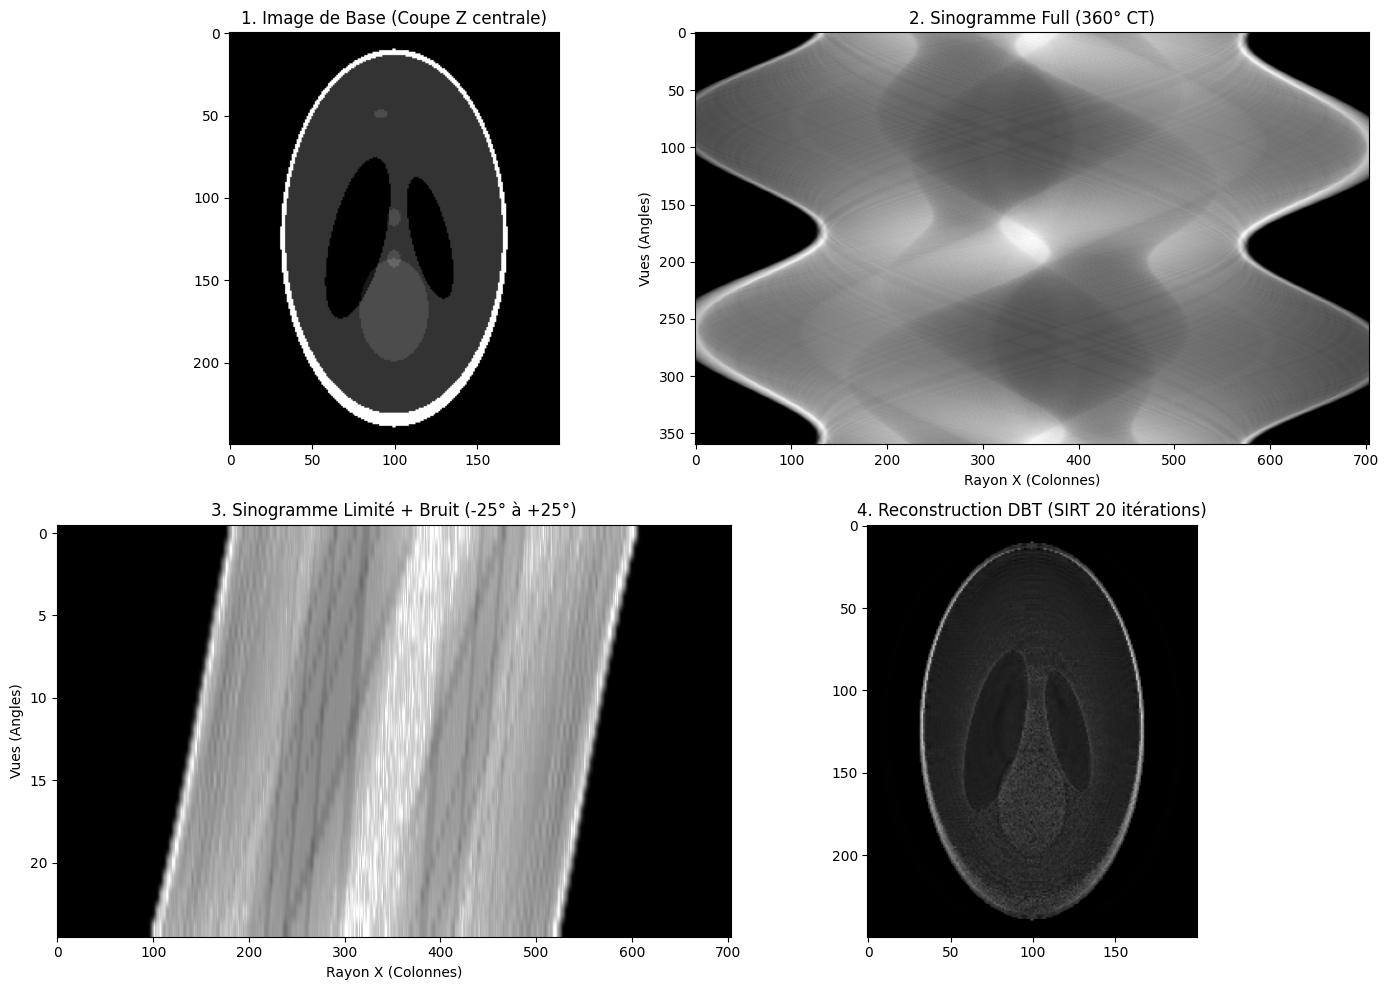

In [ ]:
import numpy as np
import odl
import astra
import matplotlib.pyplot as plt

# ==========================================
# 1. CREATE PHANTOM (Using ODL)
# ==========================================
# Define the space in ODL to generate the breast phantom
reco_space = odl.uniform_discr([-120, -150, 0], [120, 150, 60], [200, 250, 50], dtype='float32')
phantom_odl = odl.core.phantom.shepp_logan(reco_space, modified=True)

# Convert to NumPy array.
# ODL shape is (200, 250, 50) [X, Y, Z]. ASTRA expects (50, 250, 200) [Z, Y, X].
phantom_array = np.transpose(phantom_odl.asarray(), (2, 1, 0)).copy(order='C')

# ==========================================
# 2. ASTRA GEOMETRIES SETUP
# ==========================================
# Volume geometry (Z=50, Y=250, X=200)
# ASTRA implicitly centers this volume at (X=0, Y=0, Z=0) physically.
# Therefore, the physical Z-axis goes from -30 to +30 mm.
vol_geom = astra.create_vol_geom(250, 200, 50)

# Detector parameters
pixel_pitch = 0.34  # Binned pixel size
det_rows = 896      # Y axis
det_cols = 704      # X axis

# Distances mapped to ASTRA's centered coordinate system
det_z = -30.0       # Detector is at the bottom of the volume
pivot_z = 30.0      # Pivot is at the top of the volume (60 mm above detector)
src_radius = 590.0  # Distance from source to pivot

# ---- A. FULL SCAN GEOMETRY (360 degrees, CT-like, rotating detector) ----
angles_full = np.linspace(0, 2 * np.pi, 360, endpoint=False)
proj_geom_full = astra.create_proj_geom('cone', pixel_pitch, pixel_pitch, det_rows, det_cols, angles_full, src_radius, 60.0)

# ---- B. LIMITED SCAN GEOMETRY (DBT, cone_vec, fixed detector) ----
num_views = 25
angles_lim = np.linspace(np.radians(-25), np.radians(25), num_views)
vectors = np.zeros((num_views, 12))

for i, angle in enumerate(angles_lim):
    # Source moves in an arc around the pivot
    vectors[i, 0] = src_radius * np.sin(angle)
    vectors[i, 1] = 0.0
    vectors[i, 2] = src_radius * np.cos(angle) + pivot_z
    
    # Detector remains perfectly stationary at Z = -30
    vectors[i, 3] = 0.0
    vectors[i, 4] = 0.0
    vectors[i, 5] = det_z
    
    # Vector U (Pixel width along X)
    vectors[i, 6] = pixel_pitch
    vectors[i, 7] = 0.0
    vectors[i, 8] = 0.0
    
    # Vector V (Pixel height along Y)
    vectors[i, 9] = 0.0
    vectors[i, 10] = pixel_pitch
    vectors[i, 11] = 0.0

proj_geom_lim = astra.create_proj_geom('cone_vec', det_rows, det_cols, vectors)

# ==========================================
# 3. FORWARD PROJECTION (Generate Sinograms)
# ==========================================
print("Generating Full Sinogram...")
sino_id_full, sino_full = astra.create_sino3d_gpu(phantom_array, proj_geom_full, vol_geom)

print("Generating Limited Sinogram...")
sino_id_lim, sino_lim = astra.create_sino3d_gpu(phantom_array, proj_geom_lim, vol_geom)

# Add Physics-based Noise to Limited Sinogram
print("Applying Noise...")
incident_photons = 1e5
intensity = incident_photons * np.exp(-sino_lim)
noisy_intensity = np.random.poisson(intensity).astype(np.float32)
noisy_intensity += np.random.normal(0, 5.0, noisy_intensity.shape)
noisy_intensity = np.maximum(noisy_intensity, 1.0)
sino_lim_noisy = -np.log(noisy_intensity / incident_photons)

# Update the ASTRA data object with the noisy data
astra.data3d.store(sino_id_lim, sino_lim_noisy)

# ==========================================
# 4. RECONSTRUCTION (SIRT for fixed detector)
# ==========================================
print("Reconstructing DBT Volume (SIRT 20 iterations)...")
rec_id = astra.data3d.create('-vol', vol_geom)

cfg = astra.astra_dict('SIRT3D_CUDA')
cfg['ReconstructionDataId'] = rec_id
cfg['ProjectionDataId'] = sino_id_lim

alg_id = astra.algorithm.create(cfg)
astra.algorithm.run(alg_id, 20)

reconstruction = astra.data3d.get(rec_id)

# Cleanup GPU memory
astra.algorithm.delete(alg_id)
astra.data3d.delete(sino_id_full)
astra.data3d.delete(sino_id_lim)
astra.data3d.delete(rec_id)
print("Processing Complete!")

# ==========================================
# 5. VISUALIZATION (Matplotlib)
# ==========================================
# Extract middle slices
# phantom shape is (Z, Y, X) -> (50, 250, 200)
mid_z = phantom_array.shape[0] // 2
# sino shape in ASTRA is (Rows, Views, Cols) -> (896, views, 704)
mid_row = sino_full.shape[0] // 2

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# 1. Base Image
axs[0, 0].imshow(phantom_array[mid_z, :, :], cmap='gray')
axs[0, 0].set_title('1. Image de Base (Coupe Z centrale)')

# 2. Full Sinogram
axs[0, 1].imshow(sino_full[mid_row, :, :], cmap='gray', aspect='auto')
axs[0, 1].set_title('2. Sinogramme Full (360° CT)')
axs[0, 1].set_xlabel('Rayon X (Colonnes)')
axs[0, 1].set_ylabel('Vues (Angles)')

# 3. Limited Sinogram Noisy
axs[1, 0].imshow(sino_lim_noisy[mid_row, :, :], cmap='gray', aspect='auto')
axs[1, 0].set_title('3. Sinogramme Limité + Bruit (-25° à +25°)')
axs[1, 0].set_xlabel('Rayon X (Colonnes)')
axs[1, 0].set_ylabel('Vues (Angles)')

# 4. Reconstruction
# We clip the values to match the original phantom intensity range for fair visual comparison
axs[1, 1].imshow(reconstruction[mid_z, :, :], cmap='gray', vmin=0, vmax=np.max(phantom_array))
axs[1, 1].set_title('4. Reconstruction DBT (SIRT 20 itérations)')

plt.tight_layout()
plt.show()

Generating Full Sinogram (This requires ~14.5 GB VRAM)...
Generating Limited Sinogram...
Applying Noise...
Reconstructing DBT Volume (SIRT 20 iterations)...
Processing Complete!


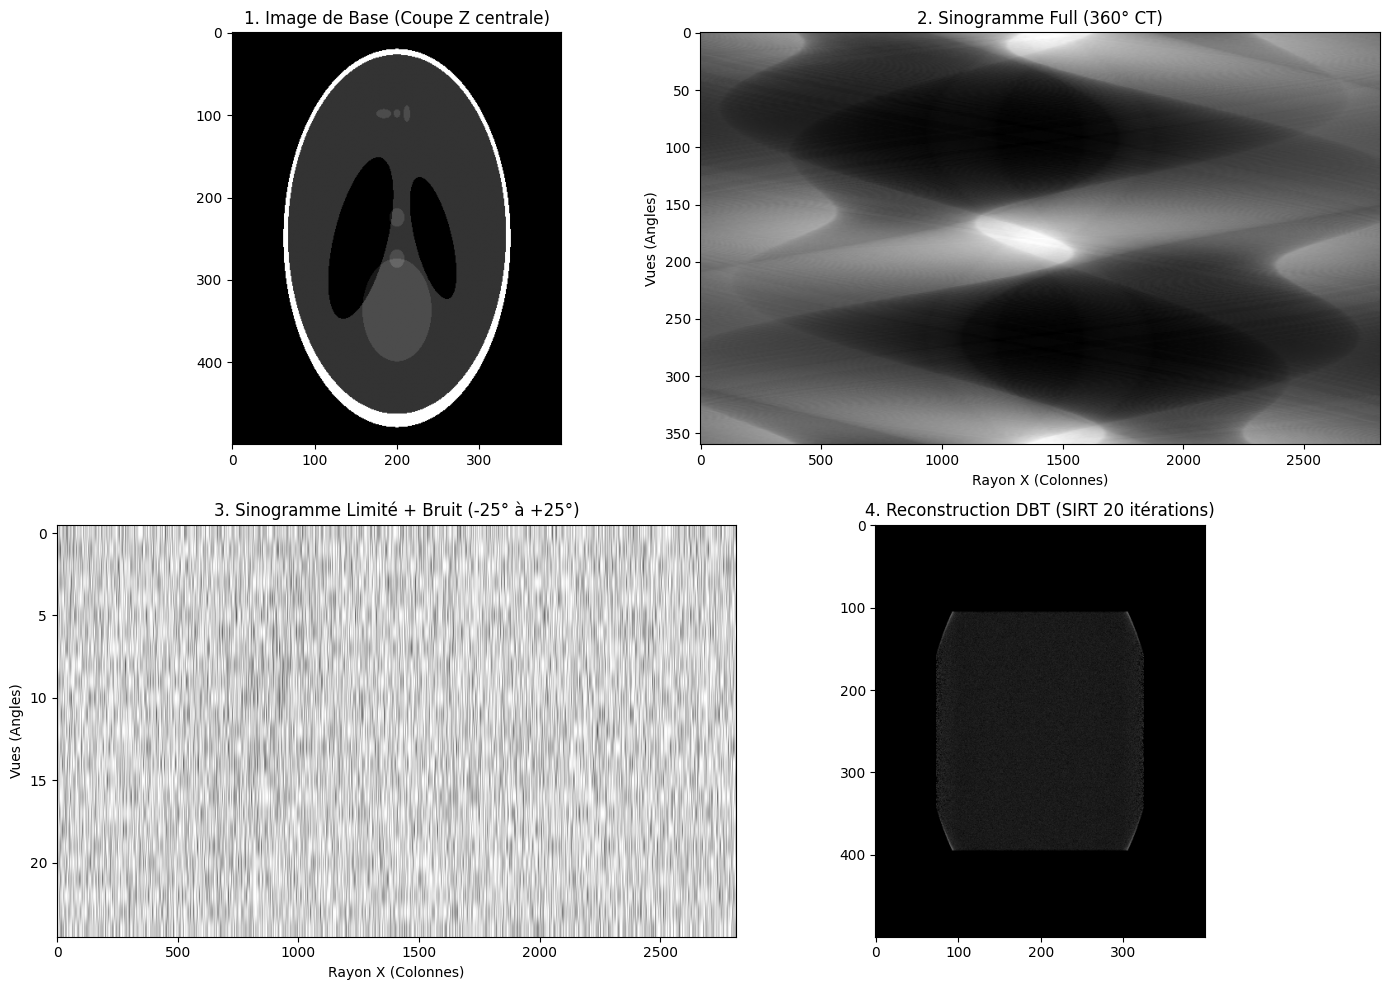

In [ ]:
import numpy as np
import odl
import astra
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

# ==========================================
# 0. CONFIGURATION
# ==========================================
# Set to True ONLY if your GPU has >16 GB of VRAM!
GENERATE_FULL_SCAN = False  

# ==========================================
# 1. CREATE PHANTOM (Using ODL)
# ==========================================
print("[1/5] Generating 3D Phantom...")
reco_space = odl.uniform_discr([-120, -150, 0], [120, 150, 60], [400, 500, 100], dtype='float32')
phantom_odl = odl.core.phantom.shepp_logan(reco_space, modified=True)

# Convert to NumPy array
phantom_array = np.transpose(phantom_odl.asarray(), (2, 1, 0)).copy(order='C')

# ---> THE FIX: Scale to realistic physical attenuation values for breast tissue (~0.05 mm^-1)
phantom_array = phantom_array * 0.05

# ==========================================
# 2. ASTRA GEOMETRIES SETUP
# ==========================================
print("[2/5] Setting up Geometries...")
# Volume geometry mapped to ASTRA (Y=500, X=400, Z=100)
vol_geom = astra.create_vol_geom(500, 400, 100)

# Exact Native Detector parameters from the paper
pixel_pitch = 0.085
det_rows = 3584     # Y axis
det_cols = 2816     # X axis

# Distances mapped to ASTRA's centered coordinate system
det_z = -30.0       # Detector is physically 30 mm below the center of the 60 mm volume
pivot_z = 30.0      # Pivot is physically 30 mm above the center (60 mm above detector)
src_radius = 590.0  # Distance from source to pivot

# ---- A. FULL SCAN GEOMETRY (360 degrees, CT-like, rotating detector) ----
if GENERATE_FULL_SCAN:
    angles_full = np.linspace(0, 2 * np.pi, 360, endpoint=False)
    proj_geom_full = astra.create_proj_geom('cone', pixel_pitch, pixel_pitch, det_rows, det_cols, angles_full, src_radius, 60.0)

# ---- B. LIMITED SCAN GEOMETRY (DBT, cone_vec, fixed detector) ----
num_views = 25
angles_lim = np.linspace(np.radians(-25), np.radians(25), num_views)
vectors = np.zeros((num_views, 12))

for i, angle in enumerate(angles_lim):
    # Source position (moves in an arc)
    vectors[i, 0] = src_radius * np.sin(angle)
    vectors[i, 1] = 0.0
    vectors[i, 2] = src_radius * np.cos(angle) + pivot_z
    
    # Detector center (stationary)
    vectors[i, 3] = 0.0
    vectors[i, 4] = 0.0
    vectors[i, 5] = det_z
    
    # Vector U (Pixel width)
    vectors[i, 6] = pixel_pitch
    vectors[i, 7] = 0.0
    vectors[i, 8] = 0.0
    
    # Vector V (Pixel height)
    vectors[i, 9] = 0.0
    vectors[i, 10] = pixel_pitch
    vectors[i, 11] = 0.0

proj_geom_lim = astra.create_proj_geom('cone_vec', det_rows, det_cols, vectors)

# ==========================================
# 3. FORWARD PROJECTION (Generate Sinograms)
# ==========================================
print("[3/5] Generating Forward Projections...")
if GENERATE_FULL_SCAN:
    print("      -> Generating Full Sinogram (This requires ~14.5 GB VRAM)...")
    sino_id_full, sino_full = astra.create_sino3d_gpu(phantom_array, proj_geom_full, vol_geom)
else:
    # Dummy data if skipped to avoid plotting errors later
    sino_full = np.zeros((det_rows, 360, det_cols))

print("      -> Generating Limited Sinogram...")
sino_id_lim, sino_lim = astra.create_sino3d_gpu(phantom_array, proj_geom_lim, vol_geom)

# Add Physics-based Noise to Limited Sinogram
print("      -> Applying Quantum and Electronic Noise...")
incident_photons = 1e5
intensity = incident_photons * np.exp(-sino_lim)
noisy_intensity = np.random.poisson(intensity).astype(np.float32)
noisy_intensity += np.random.normal(0, 5.0, noisy_intensity.shape)
noisy_intensity = np.maximum(noisy_intensity, 0.1)
sino_lim_noisy = -np.log(noisy_intensity / incident_photons)

# Overwrite ASTRA data with the noisy version
astra.data3d.store(sino_id_lim, sino_lim_noisy)

# ==========================================
# 4. RECONSTRUCTION (SIRT for fixed detector)
# ==========================================
print("[4/5] Reconstructing DBT Volume (SIRT)...")
rec_id = astra.data3d.create('-vol', vol_geom)

cfg = astra.astra_dict('SIRT3D_CUDA')
cfg['ReconstructionDataId'] = rec_id
cfg['ProjectionDataId'] = sino_id_lim

alg_id = astra.algorithm.create(cfg)

# Augmentation significative du nombre d'itérations pour un grand volume
iterations = 100 

for _ in tqdm(range(iterations), desc="      Iterating", unit="iter", color="green"):
    astra.algorithm.run(alg_id, 1)

reconstruction = astra.data3d.get(rec_id)

# Cleanup GPU memory
astra.algorithm.delete(alg_id)
if GENERATE_FULL_SCAN:
    astra.data3d.delete(sino_id_full)
astra.data3d.delete(sino_id_lim)
astra.data3d.delete(rec_id)
print("[5/5] Processing Complete! Preparing Visualization...\n")

# ==========================================
# 5. VISUALIZATION (Matplotlib - Cellules Séparées)
# ==========================================
mid_z = phantom_array.shape[0] // 2
mid_row = det_rows // 2

# Image 1 : Base
plt.figure(figsize=(10, 8))
plt.imshow(phantom_array[mid_z, :, :], cmap='gray')
plt.title('1. Image de Base (Coupe Z centrale)')
plt.colorbar(label='Atténuation')
plt.show()

# Image 2 : Full Sinogram (Si généré)
if GENERATE_FULL_SCAN:
    plt.figure(figsize=(12, 6))
    plt.imshow(sino_full[mid_row, :, :], cmap='gray', aspect='auto')
    plt.title('2. Sinogramme Full (360° CT)')
    plt.xlabel('Rayon X (Colonnes)')
    plt.ylabel('Vues (Angles)')
    plt.colorbar(label='Intensité')
    plt.show()

# Image 3 : Limited Sinogram Noisy
plt.figure(figsize=(12, 6))
plt.imshow(sino_lim_noisy[mid_row, :, :], cmap='gray', aspect='auto')
plt.title('3. Sinogramme Limité + Bruit (-25° à +25°)')
plt.xlabel('Rayon X (Colonnes)')
plt.ylabel('Vues (Angles)')
plt.colorbar(label='Intensité')
plt.show()

# Image 4 : Reconstruction
plt.figure(figsize=(10, 8))
# On utilise les valeurs min/max du fantôme original pour avoir la même échelle de contraste
plt.imshow(reconstruction[mid_z, :, :], cmap='gray', vmin=0, vmax=np.max(phantom_array))
plt.title(f'4. Reconstruction DBT (SIRT {iterations} itérations)')
plt.colorbar(label='Atténuation reconstruite')
plt.show()